# Notebook 8: PyCaret AutoML + LIME & SHAP Interpretation

**Automotive Car Price Prediction — Google Colab Extension**

---

## What this notebook does

In Notebooks 1–7 (Databricks), we manually selected, trained, and evaluated regression models. This notebook takes a different approach: we use **PyCaret**, an AutoML library, to automatically benchmark up to 20 models at once — then we interpret the best one using two state-of-the-art explainability tools.

| Step | Purpose |
|------|---------|
| Replicate preprocessing | Ensure the data fed to PyCaret is identical to what was used in Databricks |
| PyCaret AutoML | Automatically compare 20 regression models using 5-fold cross-validation |
| Tune best model | Optimise hyperparameters of the top-performing model |
| LIME | Explain *individual* predictions locally — why did the model price this specific car this way? |
| SHAP | Explain *global & local* feature importance and direction — which features drive price up or down across all cars? |
| Final comparison | Fairly compare our manually-built XGBoost (Notebook 6) against the best PyCaret model |

## Why AutoML?

Manual model selection requires expertise and trial-and-error. AutoML removes that bias — it lets the data decide which algorithm works best. If PyCaret finds a model that clearly outperforms our manual XGBoost, that is valuable insight. If XGBoost still wins, that validates our earlier manual choices.

## Why LIME and SHAP?

Modern ML models (gradient boosting, neural nets) are **black boxes** — they make accurate predictions but don't explain themselves. LIME and SHAP are two of the most widely used techniques to open up that black box:
- **LIME** is fast and intuitive for explaining one prediction at a time
- **SHAP** is mathematically rigorous and works at both the individual and global level

## Metrics used
**MAE (Mean Absolute Error)** and **RMSE (Root Mean Squared Error)**

R² measures the proportion of variance in price that the model explains.

> ⚠️ Run cells strictly top to bottom. After Cell 1 completes, **restart the runtime** before continuing.


## Step 1 — Install Dependencies

### What
Installs four libraries that are not available by default in Google Colab:
- **PyCaret [full]**: AutoML framework — includes all supported regression models (XGBoost, LightGBM, CatBoost, Random Forest, etc.)
- **LIME**: Local Interpretable Model-Agnostic Explanations
- **SHAP**: SHapley Additive exPlanations
- **Featuretools**: Automated feature engineering via Deep Feature Synthesis (DFS)

### Why the patch?
Google Colab recently upgraded its default Python version to **3.12**. PyCaret officially supports only Python 3.9–3.11 and hardcodes a check that raises a `RuntimeError` on 3.12. However, PyCaret actually *works* on 3.12 — the check is overly strict. The patch removes that version guard so we can proceed.

### ⚠️ Important — Runtime Restart Required
After this cell finishes, you **must restart the Colab runtime** before running any other cell. This forces Python to reload the newly installed package versions into memory. Skipping the restart will cause a `numpy` binary incompatibility error.

**Steps:**
1. Run this cell and wait for `✅ Installation complete`
2. Go to **Runtime → Restart Runtime**
3. Skip this cell and start from **Step 2 (Mount Drive)** onwards

In [1]:
import sys
print(f"Current Python version: {sys.version}")

# Best fix: install pycaret via pip and patch the version check
!pip install -q --upgrade pip
!pip install -q pycaret[full]
!pip install -q lime shap
!pip install -q featuretools

# ── Patch PyCaret's Python version check so it doesn't block 3.12 ──
import subprocess, pathlib

pycaret_init = pathlib.Path('/usr/local/lib/python3.12/dist-packages/pycaret/__init__.py')
if pycaret_init.exists():
    content = pycaret_init.read_text()
    if '3, 12' in content:
        patched = []
        skip = False
        for line in content.splitlines():
            if 'elif sys.version_info >= (3, 12)' in line:
                skip = True
            elif skip and line.strip().startswith('raise RuntimeError'):
                skip = True
            elif skip and not line.startswith(' ') and not line.startswith('\t') and line.strip():
                skip = False
                patched.append(line)
            elif not skip:
                patched.append(line)
        pycaret_init.write_text('\n'.join(patched))
        print("✅ PyCaret version check patched for Python 3.12 compatibility.")
    else:
        print("✅ PyCaret version check is already clean.")
else:
    print("⚠️  Could not find pycaret __init__.py to patch.")

print(f"\n✅ Installation complete. Python {sys.version_info.major}.{sys.version_info.minor}")
print("⚠️  IMPORTANT: Go to Runtime → Restart Runtime, then re-run from Cell 2 (Mount Drive) onwards.")

Current Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts

## Step 2 — Mount Google Drive & Load Data

### What to check in the output
- The shape should show **56,244 rows and 12 columns** — consistent with what was used in the Databricks pipeline
- Columns should include: `make`, `model`, `priceUSD`, `year`, `condition`, `mileage(kilometers)`, `fuel_type`, `volume(cm3)`, `color`, `transmission`, `drive_unit`, `segment`
- File path used: `/content/drive/MyDrive/cars.csv`



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

CSV_PATH = '/content/drive/MyDrive/cars.csv'

df_raw = pd.read_csv(CSV_PATH)
print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

Raw dataset shape: (56244, 12)
Columns: ['make', 'model', 'priceUSD', 'year', 'condition', 'mileage(kilometers)', 'fuel_type', 'volume(cm3)', 'color', 'transmission', 'drive_unit', 'segment']


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B


## Step 3 — Data Cleaning & Feature Engineering (Notebooks 2 + 4)

### What
Cleans the raw data using the **exact same rules** as Notebook 2 on Databricks, then applies the **same feature engineering decisions as Notebook 4**:
- Rename columns with special characters
- Lowercase all column names
- Remove invalid mileage and price entries
- Drop duplicates
- Convert `volume_cm3` to numeric
- Drop `model` (too high cardinality) and group rare makes into `make_category` — same as NB04

### What to check in the output
- Shape after cleaning should be slightly less than the raw shape (bad rows removed)
- All columns should be lowercase with no special characters


In [3]:
df = df_raw.copy()

# Rename columns to remove special characters
df = df.rename(columns={
    'mileage(kilometers)': 'mileage_kilometers',
    'volume(cm3)':         'volume_cm3'
})

# Standardise all column names to lowercase
df.columns = [c.lower().strip() for c in df.columns]

print(f"Shape before cleaning: {df.shape}")
print(f"Columns: {list(df.columns)}")

# ── Rule-based bad data removal (Notebook 2) ──
bad_mileage = df['mileage_kilometers'] >= 9_999_999
bad_price   = df['priceusd'] < 100
df = df[~bad_mileage & ~bad_price]

# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Convert volume_cm3 to numeric (sometimes stored as string)
df['volume_cm3'] = pd.to_numeric(df['volume_cm3'], errors='coerce')

# Fill missing volume_cm3 with 0 — these are electric cars (no combustion engine)
# Must be done BEFORE Featuretools so derived features (e.g. volume_cm3 * year) are correct
n_ev_nulls = df['volume_cm3'].isnull().sum()
df['volume_cm3'] = df['volume_cm3'].fillna(0)
print(f"volume_cm3: filled {n_ev_nulls} nulls with 0 (electric cars — no engine displacement)")

# ── Feature engineering (mirrors Notebook 4) ──
# Drop model — too high cardinality
df = df.drop(columns=['model'])

# Group rare makes into 'other' (same threshold as NB04)
make_counts = df['make'].value_counts()
top_makes   = make_counts[make_counts >= 100].index
df['make_category'] = df['make'].apply(lambda x: x if x in top_makes else 'other')
df = df.drop(columns=['make'])

# ── price_category for stratified split only (not a training feature) ──
p33 = df['priceusd'].quantile(0.33)
p66 = df['priceusd'].quantile(0.66)
df['price_category'] = df['priceusd'].apply(
    lambda p: 'budget' if p <= p33 else ('mid' if p <= p66 else 'luxury')
)

print(f"Shape after cleaning: {df.shape}")
print(f"\nPrice category distribution (for stratified split only):")
print(df['price_category'].value_counts().to_string())
print(f"\nMake categories: {df['make_category'].nunique()} unique values")

Shape before cleaning: (56244, 12)
Columns: ['make', 'model', 'priceusd', 'year', 'condition', 'mileage_kilometers', 'fuel_type', 'volume_cm3', 'color', 'transmission', 'drive_unit', 'segment']
volume_cm3: filled 47 nulls with 0 (electric cars — no engine displacement)
Shape after cleaning: (56133, 12)

Price category distribution (for stratified split only):
price_category
luxury    18905
mid       18659
budget    18569

Make categories: 39 unique values


---
### 📊 Output Interpretation — Data Cleaning & Feature Engineering

| Metric | Value |
|--------|-------|
| Raw dataset | 56,244 rows × 12 columns |
| After cleaning | 56,133 rows × 11 columns |
| Rows removed | 111 (0.2% — bad mileage, bad prices, duplicates) |
| `model` dropped | High cardinality — same decision as NB04 |
| `make` → `make_category` | Rare makes (< 100 cars) grouped into 'other' — same as NB04 |
| Price category split | Budget / Mid / Luxury (~33% each) |

**What this tells us:**
- Only 111 rows removed — the original data is very clean
- The three price categories are almost perfectly balanced, which is ideal for stratified splitting
- `price_category` is added purely for stratification — it is **never used as a training feature**


---

## Why We Use Featuretools in This Notebook — And Why the Comparison Is Still Valid

### Context: What Notebook 6 (Databricks) did vs what this notebook does

In Notebook 6 on Databricks, we manually created three features from domain knowledge:
- `car_age` = current year − manufacturing year
- `mileage_per_year` = mileage ÷ car age
- `make_category` = group according to car brand

Those features were then fed into three manually chosen models: **Linear Regression, Random Forest, and XGBoost**.

In this notebook (NB08), we use **Featuretools** to automatically generate features instead of crafting them by hand. These Featuretools features are what PyCaret uses to benchmark all 20 models — including Linear Regression, Random Forest, XGBoost, and CatBoost. We also retrain **XGBoost manually** (our best model from NB6) on the same Featuretools features as a direct baseline.

---

### Is the comparison fair if the features are different?

**Yes — and here is why.**

A fair comparison has two levels:

**Level 1 — Within NB08 (model vs model):**
All four models see the *exact same* Featuretools feature set, the *exact same* train/test split, and are evaluated with the *exact same* metrics. This is a perfectly controlled experiment — the only variable is the model algorithm.

| What changes | What stays fixed |
|---|---|
| Model algorithm (XGBoost manual baseline vs PyCaret's 20-model leaderboard including LR, RF, XGBoost, CatBoost) | Dataset, features, split, evaluation metric |

**Level 2 — NB06 (Databricks) vs NB08 (this notebook):**
Here the features *are* different — NB06 uses 3 hand-crafted features, NB08 uses Featuretools auto-generated features. But this difference is **intentional and informative**. It answers a second, more interesting question:

> *Does automated feature engineering (Featuretools) improve on manual feature engineering, even when the same algorithm (XGBoost) is used?*

If NB08 XGBoost outperforms NB06 XGBoost, it means Featuretools discovered useful signal that manual engineering missed. If NB06 XGBoost still wins, it means domain knowledge produced better features than brute-force search. Either outcome is a meaningful finding.

---

### Why Featuretools is the right choice for this notebook

Notebook 8's purpose is to test **how much automation helps** — at two levels:

| Dimension | NB06 approach | NB08 approach |
|-----------|--------------|--------------|
| Feature engineering | Manual (domain knowledge) | Automated (Featuretools DFS) |
| Model selection | Manual (3 chosen models) | Automated (PyCaret — 20 models) |

By automating *both* dimensions in NB08, we can compare the full manual pipeline (NB06) against the full automated pipeline (NB08) and answer the central project question:

> *How much does automation contribute compared to human expertise at each stage of the ML pipeline?*

---

### The one honest caveat

The NB06 vs NB08 comparison is not perfectly controlled — the features differ.

> *"The within-NB08 comparison is perfectly fair — all four models use identical features. The NB06 vs NB08 cross-notebook comparison is intentionally a different experiment: it tests automated feature engineering against manual feature engineering. The two experiments answer different but complementary questions."*

---

### What Featuretools actually generates (and why it likely re-discovers NB06 features)

Featuretools applies mathematical primitives to all numeric column combinations. With columns like `year`, `mileage_kilometers`, `volume_cm3`, it will automatically generate:

| Featuretools output | Equivalent manual feature |
|---------------------|--------------------------|
| `mileage_kilometers / year` | ≈ `mileage_per_year` |
| `2024 - year` (via subtraction) | ≈ `car_age` |
| `LOG(mileage_kilometers)` | log-compressed mileage |
| `mileage_kilometers * volume_cm3` | mileage–engine interaction |

The fact that Featuretools *re-discovers* the features we engineered manually in NB06 is itself a validation — it confirms our manual features were meaningful, not arbitrary. And it may find additional combinations we did not think of.

> 💡 **Key insight for your report:** If SHAP in Step 12 highlights a Featuretools-generated feature that has no direct equivalent in NB06's manual features, that is evidence that automated feature engineering found something human intuition missed.

## Step 4 — Automated Feature Engineering with Featuretools (Deep Feature Synthesis)

### What
Instead of manually crafting features like `car_age`, `mileage_per_year`, and `make_category`, we use **Featuretools** to automatically generate hundreds of candidate features from the cleaned raw columns.

This replaces the manual Notebook 4 feature engineering entirely — the goal is to let the algorithm discover which combinations of raw features are most useful, without human bias.

### How Deep Feature Synthesis (DFS) works

DFS works by applying a set of **mathematical primitives** (transformation rules) to every valid combination of numeric columns in your dataset:

| Primitive | What it creates | Example |
|-----------|----------------|---------|
| `add_numeric` | Sum of two columns | `mileage_kilometers + volume_cm3` |
| `subtract_numeric` | Difference of two columns | `year - mileage_kilometers` |
| `multiply_numeric` | Product of two columns | `mileage_kilometers * volume_cm3` |
| `divide_numeric` | Ratio of two columns | `mileage_kilometers / year` ← this is effectively `mileage_per_year`! |
| `natural_log` | Log transformation | `LOG(mileage_kilometers)` — compresses skewed distributions |
| `square_root` | Square root | `SQRT(volume_cm3)` |
| `absolute` | Absolute value | `ABS(...)` — removes sign |

With `max_depth=1`, it applies these to the original columns. With `max_depth=2`, it would apply them to features of features — exponentially more combinations, but also more noise.

### Why replace manual features?
Manual feature engineering is guided by intuition and domain knowledge. It works well but has two limitations:
1. **You only create features you think of** — you might miss important interactions
2. **Confirmation bias** — you tend to create features that confirm what you already believe matters

Featuretools is unbiased — it systematically explores all combinations. If `mileage_kilometers / year` is useful (which it is — that's `mileage_per_year`!), DFS will find it automatically.

### Important note on `max_depth`
We use `max_depth=1` here to keep the feature count manageable. `max_depth=2` can generate **thousands** of features — many of which are noise. For large datasets, this requires careful feature selection afterwards (e.g. using feature importance from a quick tree model to filter).

### What to check in the output
- DFS generated **~27 features** from 3 numeric columns (`year`, `mileage_kilometers`, `volume_cm3`) with depth=1
- The feature names will show what combinations were created (e.g. `mileage_kilometers / year`)
- Look for Featuretools automatically re-discovering `mileage / year` — this validates our earlier manual intuition

In [4]:
import featuretools as ft

# ── Step 1: Prepare input dataframe ──
# Exclude priceusd (target) and price_category (stratification) — both cause leakage.
df_ft = df.drop(columns=['priceusd', 'price_category']).copy()
df_ft['car_id'] = range(len(df_ft))

# Identify numeric and categorical columns (excluding car_id)
numeric_input_cols     = df_ft.select_dtypes(include=['number']).columns.drop('car_id').tolist()
categorical_input_cols = df_ft.select_dtypes(include=['object']).columns.tolist()
print(f"Numeric input columns ({len(numeric_input_cols)}):     {numeric_input_cols}")
print(f"Categorical input columns ({len(categorical_input_cols)}): {categorical_input_cols}")

# ── Step 2: Run DFS on NUMERIC COLUMNS ONLY ──
# Featuretools trans_primitives only work on numeric columns.
# Categorical columns marked as 'Categorical' logical type are silently dropped
# from the feature_matrix output when no applicable primitive exists.
# Solution: run DFS on numerics only, then rejoin categoricals manually afterwards.
df_numeric_only = df_ft[numeric_input_cols + ['car_id']].copy()

es = ft.EntitySet(id='cars')
es = es.add_dataframe(
    dataframe_name = 'cars',
    dataframe      = df_numeric_only,
    index          = 'car_id'
)

# ── Step 3: Run Deep Feature Synthesis (DFS) ──
feature_matrix, feature_defs = ft.dfs(
    entityset             = es,
    target_dataframe_name = 'cars',
    trans_primitives = [
        'add_numeric',
        'subtract_numeric',
        'multiply_numeric',
        'divide_numeric',
        'absolute',
        'natural_logarithm',
        'square_root',
    ],
    max_depth = 1,
    verbose   = True
)

# ── Step 4: Clean up numeric features ──
feature_matrix = feature_matrix.replace([np.inf, -np.inf], np.nan)
num_cols_fm = feature_matrix.select_dtypes(include=['number']).columns
thresh = len(feature_matrix) * 0.5
cols_to_drop = [c for c in num_cols_fm if feature_matrix[c].isna().sum() > thresh]
feature_matrix = feature_matrix.drop(columns=cols_to_drop)

# ── Step 5: Rejoin categorical columns back ──
# Reset index on both so they align row-by-row
feature_matrix = feature_matrix.reset_index(drop=True)
categorical_df = df_ft[categorical_input_cols].reset_index(drop=True)
feature_matrix = pd.concat([feature_matrix, categorical_df], axis=1)

num_feats = len(feature_matrix.select_dtypes(include=['number']).columns)
cat_feats  = len(feature_matrix.select_dtypes(include=['object']).columns)
print(f"\n✅ Featuretools feature matrix (with categoricals rejoined):")
print(f"   Numeric features:     {num_feats}")
print(f"   Categorical features: {cat_feats}  → {categorical_input_cols}")
print(f"   Total features:       {feature_matrix.shape[1]}")
print(f"\nSample numeric feature names (first 15):")
for fname in list(feature_matrix.select_dtypes(include=['number']).columns)[:15]:
    print(f"  {fname}")

# Leakage check
assert 'priceusd' not in feature_matrix.columns, "DATA LEAKAGE: priceusd in features!"
print(f"\n✅ Leakage check passed — priceusd not in feature matrix")


Numeric input columns (3):     ['year', 'mileage_kilometers', 'volume_cm3']
Categorical input columns (7): ['condition', 'fuel_type', 'color', 'transmission', 'drive_unit', 'segment', 'make_category']
Built 27 features
Elapsed: 00:01 | Progress: 100%|██████████

✅ Featuretools feature matrix (with categoricals rejoined):
   Numeric features:     27
   Categorical features: 7  → ['condition', 'fuel_type', 'color', 'transmission', 'drive_unit', 'segment', 'make_category']
   Total features:       34

Sample numeric feature names (first 15):
  year
  mileage_kilometers
  volume_cm3
  ABSOLUTE(mileage_kilometers)
  ABSOLUTE(volume_cm3)
  ABSOLUTE(year)
  mileage_kilometers + volume_cm3
  mileage_kilometers + year
  volume_cm3 + year
  mileage_kilometers / volume_cm3
  mileage_kilometers / year
  volume_cm3 / mileage_kilometers
  volume_cm3 / year
  year / mileage_kilometers
  year / volume_cm3

✅ Leakage check passed — priceusd not in feature matrix


---
### 📊 Output Interpretation — Featuretools DFS

| Metric | Value |
|--------|-------|
| Numeric input columns | 3: `year`, `mileage_kilometers`, `volume_cm3` |
| Numeric features generated by DFS | 27 (combinations + transformations) |
| Categorical columns rejoined manually | 7: `make_category`, `fuel_type`, `color`, `transmission`, `drive_unit`, `segment`, `condition` |
| Total features in matrix | 34 (before OHE) |
| Leakage check | ✅ Passed — `priceusd` not in feature matrix |

**Why we run DFS on numerics only, then rejoin categoricals:**
Featuretools `trans_primitives` (add, subtract, multiply, divide, log, sqrt) only apply to numeric columns. When categorical columns are included in the EntitySet, Featuretools silently drops them from the output because no primitive can be applied to text. The fix is to run DFS on numeric columns only, then manually `pd.concat` the categorical columns back onto the feature matrix.

**What Featuretools generated from the 3 numeric columns (sample):**

| Generated feature | What it means |
|-------------------|---------------|
| `mileage_kilometers / year` | Usage intensity — same concept as our manual `mileage_per_year` |
| `ABSOLUTE(mileage_kilometers)` | Absolute value of mileage |
| `mileage_kilometers + volume_cm3` | Combined mileage-engine signal |
| `volume_cm3 / year` | Engine size relative to car age |
| `year / mileage_kilometers` | Inverse usage intensity |

**What happens to the categorical columns next:**
The 7 categorical columns (`make_category`, `fuel_type`, `transmission`, `drive_unit`, `segment`, `condition`, `color`) are One-Hot Encoded in Step 6 — each becomes a set of binary (0/1) columns (e.g. `make_category_bmw=1`, `fuel_type_diesel=1`). After OHE the total feature count expands to **100**.

## Step 4b — Align Featuretools Output with Target & Split

### What
Reconnects the Featuretools-generated feature matrix with the target column (`priceusd`) and the `price_category` stratification column, so we can perform the same stratified train/test split as the rest of the pipeline.

### Why this step is needed
Featuretools outputs a new DataFrame (`feature_matrix`) indexed by `car_id`. We need to:
1. Align it back to the original DataFrame by index so targets match rows
2. Add back `priceusd` (the target) which was excluded during DFS
3. Add back `price_category` (for stratified split only — not a training feature)

### What to check
- Row counts must match exactly between `feature_matrix` and `df`
- No rows should be lost during the alignment

In [5]:
# ── Align feature_matrix back to original df by car_id index ──
# feature_matrix index = car_id (0 to N-1), df index is also 0 to N-1 after reset_index
feature_matrix = feature_matrix.reset_index(drop=True)

# Add the target and stratification columns back
feature_matrix['priceusd']      = df['priceusd'].values
feature_matrix['price_category'] = df['price_category'].values

print(f"Final feature matrix shape (with target): {feature_matrix.shape}")
print(f"Columns sample: {list(feature_matrix.columns[:10])}")
print(f"\nTarget column range: ${feature_matrix['priceusd'].min():,.0f} — ${feature_matrix['priceusd'].max():,.0f}")
print(f"Price category distribution:")
print(feature_matrix['price_category'].value_counts().to_string())

Final feature matrix shape (with target): (56133, 36)
Columns sample: ['year', 'mileage_kilometers', 'volume_cm3', 'ABSOLUTE(mileage_kilometers)', 'ABSOLUTE(volume_cm3)', 'ABSOLUTE(year)', 'mileage_kilometers + volume_cm3', 'mileage_kilometers + year', 'volume_cm3 + year', 'mileage_kilometers / volume_cm3']

Target column range: $100 — $235,235
Price category distribution:
price_category
luxury    18905
mid       18659
budget    18569


## Step 5 — Stratified Train / Test Split

### What
Splits the Featuretools-generated feature matrix into **80% training** and **20% test** sets using stratified sampling on `price_category`.

### Why the same split strategy?
Using the same `random_state=42` and stratification approach as Notebook 5 ensures that:
- The **test set is a fair, representative sample** of all price segments
- The comparison between manual XGBoost, PyCaret (manual features), and PyCaret (Featuretools features) is on **equivalent data**

### What to check in the output
- Train: ~80% of rows, Test: ~20% of rows
- Budget / mid / luxury percentages should be nearly identical in both splits

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error

target_col   = 'priceusd'
stratify_col = feature_matrix['price_category']

X = feature_matrix.drop(columns=[target_col, 'price_category'])
y = feature_matrix[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_col
)

print(f"Train: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Features: {X_train.shape[1]}")

# Verify stratification
train_dist = stratify_col[X_train.index].value_counts(normalize=True).sort_index()
test_dist  = stratify_col[X_test.index].value_counts(normalize=True).sort_index()
print(f"\nStratification check:")
print(f"{'Category':<10} {'Train %':>10} {'Test %':>10}")
print("-" * 32)
for cat in train_dist.index:
    print(f"{cat:<10} {train_dist[cat]*100:>9.1f}% {test_dist[cat]*100:>9.1f}%")

Train: 44,906 samples (80%)
Test:  11,227 samples (20%)
Features: 34

Stratification check:
Category      Train %     Test %
--------------------------------
budget          33.1%      33.1%
luxury          33.7%      33.7%
mid             33.2%      33.2%


---
### 📊 Output Interpretation — Stratified Train/Test Split

| Split | Rows | % |
|-------|------|---|
| Train | 44,906 | 80% |
| Test | 11,227 | 20% |
| Features | 34 | — |

**Stratification result:**

| Category | Train % | Test % |
|----------|---------|--------|
| Budget | 33.1% | 33.1% |
| Mid | 33.2% | 33.2% |
| Luxury | 33.7% | 33.7% |

**What this tells us:**
- The stratified split worked perfectly — train and test sets have **identical price category distributions** (within rounding)
- This means our test set is a genuine representative sample of all car types, not accidentally dominated by cheap or expensive cars
- Without stratification, random splitting on a skewed price distribution could leave the luxury segment under-represented in training, leading to poor luxury car predictions


## Step 6 — Imputation, Scaling & One-Hot Encoding

### What
Applies preprocessing to the full feature matrix — both the Featuretools-generated numeric features and the 7 categorical columns that were rejoined after DFS.

Two separate pipelines run in sequence, then the results are combined:

**Numeric features** (Featuretools output — e.g. `mileage_kilometers / year`, `NATURAL_LOGARITHM(mileage_kilometers)`, `volume_cm3 * year`):
- **Median imputation** → fills NaN values created by division-by-zero or log of negatives
- **StandardScaler** → normalises all features to mean=0, std=1

**Categorical features** (`make_category`, `fuel_type`, `color`, `transmission`, `drive_unit`, `segment`, `condition`):
- **Most-frequent imputation** → fills any missing category with the most common value
- **One-Hot Encoding (OHE)** → converts each category into binary (0/1) columns (e.g. `make_category` → `make_category_bmw`, `make_category_toyota`, etc.)

The two processed arrays are then combined horizontally into a single feature matrix.

### Why fit only on training data?
The imputers, scaler, and encoder are all **fitted on training data only**. The test set must never influence the fitting — otherwise test-set statistics would leak into the model's training process.

In [7]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Separate numeric and categorical columns
numeric_cols     = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features:     {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
if categorical_cols:
    print(f"  → {categorical_cols}")

# ── Numeric: impute with median → scale ──
num_imputer  = SimpleImputer(strategy='median')
X_train_num  = num_imputer.fit_transform(X_train[numeric_cols])
X_test_num   = num_imputer.transform(X_test[numeric_cols])

scaler       = StandardScaler()
X_train_num  = scaler.fit_transform(X_train_num)
X_test_num   = scaler.transform(X_test_num)

# ── Categorical: impute with most_frequent → One-Hot Encode ──
# fit only on training data to prevent data leakage
if categorical_cols:
    cat_imputer  = SimpleImputer(strategy='most_frequent')
    X_train_cat_raw = cat_imputer.fit_transform(X_train[categorical_cols])
    X_test_cat_raw  = cat_imputer.transform(X_test[categorical_cols])

    encoder      = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_cat  = encoder.fit_transform(X_train_cat_raw)
    X_test_cat   = encoder.transform(X_test_cat_raw)
    cat_names    = encoder.get_feature_names_out(categorical_cols).tolist()

    X_train_processed = np.hstack([X_train_num, X_train_cat])
    X_test_processed  = np.hstack([X_test_num,  X_test_cat])
    all_feature_names = numeric_cols + cat_names

    print(f"\nAfter OHE — categorical columns expanded:")
    for col in categorical_cols:
        n_cats = len([c for c in cat_names if c.startswith(col + '_')])
        print(f"  {col:<20} → {n_cats} binary columns")
else:
    X_train_processed = X_train_num
    X_test_processed  = X_test_num
    all_feature_names = numeric_cols

# Back to DataFrames (needed for LIME, SHAP, PyCaret)
X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test_df  = pd.DataFrame(X_test_processed,  columns=all_feature_names)
y_train    = y_train.reset_index(drop=True)
y_test     = y_test.reset_index(drop=True)

print(f"\nProcessed train shape: {X_train_df.shape}")
print(f"Processed test shape:  {X_test_df.shape}")
print(f"Total features:        {len(all_feature_names)}")
print(f"  Numeric:             {len(numeric_cols)}")
print(f"  One-hot encoded:     {len(all_feature_names) - len(numeric_cols)}")


Numeric features:     27
Categorical features: 7
  → ['condition', 'fuel_type', 'color', 'transmission', 'drive_unit', 'segment', 'make_category']

After OHE — categorical columns expanded:
  condition            → 3 binary columns
  fuel_type            → 3 binary columns
  color                → 13 binary columns
  transmission         → 2 binary columns
  drive_unit           → 4 binary columns
  segment              → 9 binary columns
  make_category        → 39 binary columns

Processed train shape: (44906, 100)
Processed test shape:  (11227, 100)
Total features:        100
  Numeric:             27
  One-hot encoded:     73


---
### 📊 Output Interpretation — Imputation & Scaling

| Metric | Value |
|--------|-------|
| Numeric features | 27 Featuretools-generated numeric features |
| Categorical features | 7 columns: `make_category`, `fuel_type`, `color`, `transmission`, `drive_unit`, `segment`, `condition` |
| After OHE expansion | **100 total features** (27 numeric + 73 OHE columns) |

**OHE breakdown — how 7 categorical columns became 73 binary columns:**

| Column | Unique values | Binary columns created |
|--------|--------------|----------------------|
| `condition` | 3 | 3 |
| `fuel_type` | 3 | 3 |
| `color` | 13 | 13 |
| `transmission` | 2 | 2 |
| `drive_unit` | 4 | 4 |
| `segment` | 9 | 9 |
| `make_category` | 39 | 39 |
| **Total** | | **73 binary columns** |

**Numeric features** — median imputation + StandardScaler:
- All 27 Featuretools-generated numeric combinations imputed with median and scaled to mean=0, std=1
- Scaling makes LR coefficients directly comparable across features

**Categorical features** — most_frequent imputation + One-Hot Encoding:
- `make_category`: 39 unique values (top makes + 'other') → 39 binary columns
- `color`: 13 unique colours → 13 binary columns
- `segment`: 9 unique segments → 9 binary columns
- `drive_unit`: 4 types → 4 binary columns
- `condition`, `fuel_type`, `transmission`: 3, 3, 2 binary columns respectively

**Why OHE on categoricals?**
XGBoost, LR, and Random Forest cannot use raw text labels — they need numbers. OHE converts each category into a binary (0/1) column. CatBoost can handle categoricals natively, but since we pre-process before passing to all models, OHE is the consistent approach.

**Why fit only on training data?**
The imputer and encoder are fitted on training data only. This prevents leakage — the test set must never influence how we handle missing values or what categories we know about.

## Step 7 — Manual XGBoost Baseline

### What
Re-trains the same XGBoost model from Notebook 6 using the **exact same hyperparameters** (`n_estimators=100`, `learning_rate=0.1`) on this notebook's training set. We evaluate it on both train and test to establish a baseline before introducing PyCaret.

### Why retrain here instead of loading from MLflow?
The MLflow-saved model from Notebook 6 was trained on Databricks with a specific data version. If we loaded it here and compared it against PyCaret models trained on slightly different data, the comparison would be unfair. By retraining with identical hyperparameters on the same data split, we ensure an **apples-to-apples comparison**.

### Why check both train and test metrics?
- **Train MAE** tells us how well the model fits the data it learned from
- **Test MAE** tells us how well it generalises to unseen data
- A **large gap** between train and test MAE signals overfitting — the model memorised training data instead of learning patterns
- A **small gap** (< 20% of train MAE) is expected and healthy

### What to watch for
- If train MAE is much lower than test MAE, the model is overfitting
- The XGBoost baseline numbers here are your **benchmark** — PyCaret must beat these to justify using AutoML

In [9]:
from xgboost import XGBRegressor

def get_metrics(y_true, y_pred, label):
    """Return MAE and RMSE as a dict."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'label': label, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)}

# Train manual XGBoost (same hyperparameters as Notebook 6)
xgb_manual = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_manual.fit(X_train_df, y_train)

# Train & test predictions
y_train_pred_xgb = xgb_manual.predict(X_train_df)
y_test_pred_xgb  = xgb_manual.predict(X_test_df)

xgb_train_metrics = get_metrics(y_train, y_train_pred_xgb, 'Manual XGBoost — Train')
xgb_test_metrics  = get_metrics(y_test,  y_test_pred_xgb,  'Manual XGBoost — Test')

print("Manual XGBoost (Notebook 6 reference):")
print(f"  Train  →  MAE: ${xgb_train_metrics['MAE']:>10,.2f}   RMSE: ${xgb_train_metrics['RMSE']:>10,.2f}")
print(f"  Test   →  MAE: ${xgb_test_metrics['MAE']:>10,.2f}   RMSE: ${xgb_test_metrics['RMSE']:>10,.2f}")

mae_gap  = xgb_test_metrics['MAE']  - xgb_train_metrics['MAE']
rmse_gap = xgb_test_metrics['RMSE'] - xgb_train_metrics['RMSE']
print(f"  Gap    →  MAE: ${mae_gap:>+10,.2f}   RMSE: ${rmse_gap:>+10,.2f}")
print("  (Positive gap means slightly worse on test — expected and acceptable)")

Manual XGBoost (Notebook 6 reference):
  Train  →  MAE: $  1,144.93   RMSE: $  2,046.63
  Test   →  MAE: $  1,247.93   RMSE: $  2,810.23
  Gap    →  MAE: $   +103.00   RMSE: $   +763.60
  (Positive gap means slightly worse on test — expected and acceptable)


### Output Interpretation — Manual XGBoost Baseline

| Metric | Train | Test | Gap |
|---|---|---|---|
| MAE  | 💲1,144.93 | 💲1,247.93 | +💲103.00 |
| RMSE | 💲2,046.63 | 💲2,810.23 | +💲763.60 |

**What this tells us:**
- **Test RMSE of 💲2,810** is our primary benchmark — it penalises large errors (e.g., luxury car mispredictions) more heavily than MAE
- **Test MAE of 💲1,248** is the secondary metric — on average the model predicts within ~💲1,248 of the actual price
- The **MAE gap of 💲103** (test − train) is only 9.0% of the train MAE — the model is not overfitting and generalises well to unseen cars
- The **RMSE gap is larger (💲764)** than the MAE gap — this tells us the model makes a few larger errors on outlier cars (likely the luxury segment), even though typical errors are manageable
- This is our benchmark: **PyCaret must beat 💲2,810 test RMSE** to justify the AutoML approach (RMSE is our primary metric — it penalises large luxury car errors more heavily)

**Why RMSE >> MAE here:** RMSE = 💲2,810 vs MAE = 💲1,248 — the ratio is ~2.25×. A ratio above 1.5× suggests the model is making some very large errors on a small number of cars (the luxury tail). The average error is 💲1,248, but the worst predictions are much larger.

## Step 8 — PyCaret Setup

### What
Initialises PyCaret's regression environment using the training set only. This `setup()` call tells PyCaret everything it needs to know about the data before it starts benchmarking models.

### Why pass only the training set?
The test set is our held-out evaluation data — PyCaret must never see it during training or cross-validation. By passing only `X_train_df + y_train`, we ensure the test set remains a true simulation of unseen real-world data.

### What does PyCaret's `setup()` do internally?
- Detects feature types (numeric vs categorical)
- Sets up the cross-validation strategy (5-fold here)
- Prepares the pipeline for each model it will test
- Sets the random seed for reproducibility (`session_id=42`)

### Why 5-fold cross-validation?
Instead of a single train/validation split, 5-fold CV splits the training set into 5 equal parts, trains on 4 and validates on 1, five times — each time using a different part as the validation set. The final score is the **average across all 5 folds**. This gives a much more robust and reliable estimate of model performance than a single split.

### What to check in the output
- PyCaret will print a configuration table — verify that the target column is `priceusd` and the number of features matches what we built in Step 5
- If you see any warnings about missing values or feature types, those are usually non-critical

In [10]:
from pycaret.regression import (
    setup, compare_models, tune_model, finalize_model,
    predict_model, pull, get_config
)

# Combine X_train + y_train into one DataFrame for PyCaret
train_pycaret = X_train_df.copy()
train_pycaret['priceusd'] = y_train.values

# PyCaret setup — use MAE as the optimisation metric
# fold=5 for 5-fold cross validation on train set
reg = setup(
    data            = train_pycaret,
    target          = 'priceusd',
    session_id      = 42,
    fold            = 5,
    verbose         = True
)

print("PyCaret setup complete.")

,Description,Value
0,Session id,42
1,Target,priceusd
2,Target type,Regression
3,Original data shape,"(44906, 101)"
4,Transformed data shape,"(44906, 101)"
5,Transformed train set shape,"(31434, 101)"
6,Transformed test set shape,"(13472, 101)"
7,Numeric features,100
8,Preprocess,True
9,Imputation type,simple


PyCaret setup complete.


## Step 9 — Compare 20 Models with PyCaret

### What
PyCaret trains and evaluates up to 20 different regression algorithms using 5-fold cross-validation on the training set. Results are sorted by **RMSE (ascending)** — the model with the lowest RMSE appears first.

### Models that PyCaret typically evaluates
| Category | Models |
|----------|--------|
| Tree-based ensembles | XGBoost, LightGBM, CatBoost, Random Forest, Extra Trees, Gradient Boosting |
| Linear models | Ridge, Lasso, ElasticNet, Bayesian Ridge, Huber Regressor |
| Other | K-Nearest Neighbors, Decision Tree, Dummy Regressor, Orthogonal Matching Pursuit, Passive Aggressive, etc. |

### Why sort by RMSE and not MAE?
RMSE is our primary metric because it penalises large errors more heavily by squaring them first. In car pricing, a 💲10,000 mistake on a luxury car is far worse than ten 💲1,000 mistakes on budget cars — RMSE captures that asymmetry. MAE treats every dollar of error equally, which is less appropriate when luxury car mispredictions can be catastrophically large.

### Why exclude R²?
R² measures what proportion of variance the model explains. On a dataset with a wide, skewed price range (budget cars at 💲1,000 to luxury cars at 💲100,000+), R² can look artificially high even when the model is making large dollar errors. MAE and RMSE give us a direct, interpretable dollar error — which is what matters in practice.

### What to look for in the results
- The **top 3 models by RMSE** — these are our candidates (lowest RMSE = best at minimising large errors)
- Also check **MAE** — it tells us the average dollar error across all cars (secondary metric)
- Tree-based ensembles (XGBoost, LightGBM, CatBoost) almost always dominate on tabular data like this



In [11]:
# Compare all available models sorted by RMSE (our primary metric)
# n_select=20 keeps top 20 models for review
best_models = compare_models(
    sort        = 'RMSE',
    n_select    = 20,
    verbose     = True
)

# Pull the results table
comparison_results = pull()

# Drop R² related columns to keep our agreed metrics
cols_to_drop = [c for c in comparison_results.columns if 'R2' in c or 'RMSLE' in c or 'MAPE' in c]
comparison_results_clean = comparison_results.drop(columns=cols_to_drop, errors='ignore')

print("\nPyCaret Model Comparison (sorted by RMSE — CV on train set):")
print(comparison_results_clean.to_string())

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,1210.7960,7642949.0741,2749.8774,0.8895,0.3481,0.2647,17.8540
xgboost,Extreme Gradient Boosting,1237.7271,8833752.8034,2959.3243,0.8734,0.3497,0.2655,1.9040
et,Extra Trees Regressor,1254.9085,9077506.1226,2999.9368,0.8689,0.3334,0.2604,51.0340
lightgbm,Light Gradient Boosting Machine,1317.4276,9303015.0971,3040.7607,0.8657,0.3688,0.2921,3.0900
rf,Random Forest Regressor,1254.5102,9477154.8206,3070.9861,0.8632,0.3312,0.2627,84.8660
gbr,Gradient Boosting Regressor,1536.8792,10518486.4779,3228.2575,0.8482,0.4073,0.3520,20.4580
knn,K Neighbors Regressor,1481.2914,11456851.9181,3371.4466,0.8358,0.3836,0.3244,2.5620
dt,Decision Tree Regressor,1675.9091,20080436.1894,4395.2906,0.7089,0.4262,0.3258,1.6260
br,Bayesian Ridge,2235.6511,24065224.3534,4896.7930,0.6569,0.7703,0.6331,1.1060
ada,AdaBoost Regressor,3673.9529,27742885.6665,5255.6631,0.5996,0.9200,1.5675,5.8560


Processing:   0%|          | 0/104 [00:00<?, ?it/s]


PyCaret Model Comparison (sorted by RMSE — CV on train set):
                                    Model           MAE           MSE          RMSE  TT (Sec)
catboost               CatBoost Regressor  1.210796e+03  7.642949e+06  2.749877e+03    17.854
xgboost         Extreme Gradient Boosting  1.237727e+03  8.833753e+06  2.959324e+03     1.904
et                  Extra Trees Regressor  1.254909e+03  9.077506e+06  2.999937e+03    51.034
lightgbm  Light Gradient Boosting Machine  1.317428e+03  9.303015e+06  3.040761e+03     3.090
rf                Random Forest Regressor  1.254510e+03  9.477155e+06  3.070986e+03    84.866
gbr           Gradient Boosting Regressor  1.536879e+03  1.051849e+07  3.228258e+03    20.458
knn                 K Neighbors Regressor  1.481291e+03  1.145685e+07  3.371447e+03     2.562
dt                Decision Tree Regressor  1.675909e+03  2.008044e+07  4.395291e+03     1.626
br                         Bayesian Ridge  2.235651e+03  2.406522e+07  4.896793e+03     1.10

### Output Interpretation — PyCaret Model Comparison (20 Models, 5-fold CV)

| Rank | Model | CV RMSE (**primary**) | CV MAE |
|---|---|---|---|
| 1 | CatBoost          | 💲2,750 | 💲1,211 |
| 2 | XGBoost           | 💲2,959 | 💲1,238 |
| 3 | Extra Trees       | 💲3,000 | 💲1,255 |
| 4 | Random Forest     | 💲3,071 | 💲1,255 |
| 5 | LightGBM          | 💲3,041 | 💲1,317 |
| 6 | KNN               | 💲3,371 | 💲1,481 |
| 7 | Gradient Boosting | 💲3,228 | 💲1,537 |
| 8 | Decision Tree     | 💲4,395 | 💲1,676 |
| 9 | Linear Regression | 💲5,261 | 💲2,344 |

**Key observations:**
- **CatBoost wins** with CV RMSE 💲2,750 — selected as best model (lowest RMSE = fewest large errors)
- CatBoost beats XGBoost by 💲209 RMSE — meaningful advantage at handling luxury car outliers
- Top 4 models are all tree ensembles — confirms the data is non-linear
- Linear Regression (💲5,261 RMSE) vs CatBoost (💲2,750 RMSE) — AutoML finds ~48% better RMSE than a linear model

## Step 10 — Select & Tune the Best PyCaret Model *

### What
Takes the top model from `compare_models()` (rank 1 by MAE) and runs hyperparameter tuning using **Random Search** with 50 iterations. The goal is to squeeze more performance out of the best model by finding better hyperparameter values.

### What is hyperparameter tuning?
Every ML model has settings that are not learned from data — they are set before training begins. For example, in XGBoost:
- `n_estimators`: how many trees to build
- `learning_rate`: how much each tree corrects the previous one
- `max_depth`: how deep each tree can grow

Tuning searches through combinations of these settings to find the one that gives the lowest cross-validated MAE.

### Why Random Search (not Grid Search)?
Grid Search tries every possible combination — exponentially slow for many hyperparameters. Random Search randomly samples 50 combinations from the search space and is usually **90% as effective at 10% of the cost**.

### What `finalize_model()` does
After tuning, PyCaret refits the best hyperparameter configuration on **100% of the training data** (not just 80% of it used during CV). This gives the model access to the maximum possible training data before it is evaluated on the test set.

### What to look for
- The tuned model's CV MAE should be **equal to or lower** than the base model's CV MAE
- If tuning makes the score worse, PyCaret will revert to the base hyperparameters automatically
- The printed model parameters show exactly what configuration was selected

In [13]:
# Select the best model (top of the leaderboard by RMSE)
best_model = best_models[0] if isinstance(best_models, list) else best_models
print(f"Best model selected: {type(best_model).__name__}")

# Tune hyperparameters — optimise for RMSE (primary metric)
print("\nTuning best model...")
tuned_model = tune_model(
    best_model,
    optimize   = 'RMSE',
    n_iter     = 50,
    verbose    = True
)

# Pull tuning results
tuning_results = pull()
print(f"\nTuned {type(tuned_model).__name__} CV results:")
print(tuning_results.to_string())

Best model selected: CatBoostRegressor

Tuning best model...


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1640.0035,11985159.5732,3461.9589,0.8369,0.4968,0.4951
1,1648.1623,13038683.3763,3610.9117,0.8055,0.5108,0.5204
2,1669.6999,8954394.5661,2992.3894,0.8668,0.5038,0.5067
3,1668.0581,12506714.6875,3536.4834,0.8015,0.4981,0.4943
4,1696.1064,12470529.5295,3531.3637,0.8420,0.5151,0.5233
Mean,1664.4060,11791096.3465,3426.6214,0.8305,0.5049,0.5079
Std,19.5224,1457034.6588,222.1755,0.0243,0.0071,0.0122


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).

Tuned CatBoostRegressor CV results:
            MAE           MSE       RMSE      R2   RMSLE    MAPE
Fold                                                            
0     1640.0035  1.198516e+07  3461.9589  0.8369  0.4968  0.4951
1     1648.1623  1.303868e+07  3610.9117  0.8055  0.5108  0.5204
2     1669.6999  8.954395e+06  2992.3894  0.8668  0.5038  0.5067
3     1668.0581  1.250671e+07  3536.4834  0.8015  0.4981  0.4943
4     1696.1064  1.247053e+07  3531.3637  0.8420  0.5151  0.5233
Mean  1664.4060  1.179110e+07  3426.6214  0.8305  0.5049  0.5079
Std     19.5224  1.457035e+06   222.1755  0.0243  0.0071  0.0122


### Output Interpretation — Tuning & Finalization

| Stage | CV MAE | Notes |
|---|---|---|
| Base CatBoost (`compare_models`) | 💲1,211 | Default hyperparameters, 5-fold CV |
| After `tune_model()`             | 💲1,664 (worse — reverted) | 50 random configs searched, all worse |
| After `finalize_model()`         | 💲1,162 (test MAE) | Retrained on 100% of training data |

**Why tuning made it worse:** All 50 searched hyperparameter configs produced higher CV error than the defaults. PyCaret automatically reverted to the original model — this is expected behaviour, not a bug.

**Why `finalize_model()` improved results:** During CV, the model only sees 80% of the training set (~35,924 rows). After finalizing, it trains on all 44,906 rows — more data leads to better generalisation, which is why test MAE drops from 💲1,211 (CV estimate) to 💲1,162 (actual test).

In [14]:
# Finalize — refit on 100% of training data
final_model = finalize_model(tuned_model)
print(f"Model finalised: {type(final_model).__name__}")
print(f"\nModel parameters:")
print(final_model)

Model finalised: Pipeline

Model parameters:
Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['year', 'mileage_kilometers',
                                             'volume_cm3',
                                             'ABSOLUTE(mileage_kilometers)',
                                             'ABSOLUTE(volume_cm3)',
                                             'ABSOLUTE(year)',
                                             'mileage_kilometers + volume_cm3',
                                             'mileage_kilometers + year',
                                             'volume_cm3 + year',
                                             'mileage_kilometers / volume_cm3',
                                             'mileage_kilometers / year',
                                             'volume_cm...
                                             'condition_with mileage', ...],
                         

## Step 11 — Evaluate PyCaret Best Model on Train & Test

### What
Runs the finalised PyCaret model on both the training set and the held-out test set, computing MAE and RMSE for each. This is the first time the model has ever seen the test data.

### Why evaluate on both train and test?
Cross-validation during PyCaret's `compare_models()` gives a good estimate of generalisation, but it's still based on the training data. The **final test set evaluation** is the most honest measure of how the model will perform on real-world unseen cars.

Evaluating on train as well lets us detect **overfitting**:
- If train MAE ≈ test MAE → the model generalises well ✅
- If train MAE << test MAE → the model memorised training data (overfitting) ⚠️

### What to look for
- **MAE gap** (test − train): a gap of ~10–20% of the train MAE is normal and expected
- A gap larger than 20% of train MAE suggests overfitting and the model may need more regularisation
- Compare these numbers directly against the XGBoost baseline from Step 6 — if PyCaret's test MAE is lower, AutoML won this round

In [15]:
# Predict on train set
train_pred_df = predict_model(final_model, data=X_train_df)
y_train_pred_pycaret = train_pred_df['prediction_label'].values

# Predict on test set
test_pred_df = predict_model(final_model, data=X_test_df)
y_test_pred_pycaret = test_pred_df['prediction_label'].values

pycaret_train_metrics = get_metrics(y_train, y_train_pred_pycaret, 'PyCaret Best — Train')
pycaret_test_metrics  = get_metrics(y_test,  y_test_pred_pycaret,  'PyCaret Best — Test')

model_name = type(final_model).__name__

print(f"PyCaret Best Model ({model_name}):")
print(f"  Train  →  MAE: ${pycaret_train_metrics['MAE']:>10,.2f}   RMSE: ${pycaret_train_metrics['RMSE']:>10,.2f}")
print(f"  Test   →  MAE: ${pycaret_test_metrics['MAE']:>10,.2f}   RMSE: ${pycaret_test_metrics['RMSE']:>10,.2f}")

mae_gap  = pycaret_test_metrics['MAE']  - pycaret_train_metrics['MAE']
rmse_gap = pycaret_test_metrics['RMSE'] - pycaret_train_metrics['RMSE']
overfit_flag = 'OVERFITTING' if mae_gap > xgb_test_metrics['MAE'] * 0.1 else 'OK'
print(f"  Gap    →  MAE: ${mae_gap:>+10,.2f}   RMSE: ${rmse_gap:>+10,.2f}  [{overfit_flag}]")

PyCaret Best Model (Pipeline):
  Train  →  MAE: $  1,030.50   RMSE: $  1,714.06
  Test   →  MAE: $  1,162.29   RMSE: $  2,514.53
  Gap    →  MAE: $   +131.79   RMSE: $   +800.47  [OVERFITTING]


### Output Interpretation — PyCaret CatBoost Final Evaluation

| Model | Train MAE | Test MAE | Train RMSE | Test RMSE | MAE Gap | Winner? |
|---|---|---|---|---|---|---|
| Manual XGBoost (with Featuretools) | 💲1,144.93 | 💲1,247.93 | 💲2,046.63 | 💲2,810.23 | +💲103.00 | No  |
| PyCaret CatBoost         | 💲1,030.50 | 💲1,162.29 | 💲1,714.06 | 💲2,514.53 | +💲131.79 | ✅ Yes |

**PyCaret CatBoost wins** — beats the manual XGBoost baseline by **💲295.70 RMSE (10.5%)** (primary metric).

**What this tells us:**
- CatBoost test **RMSE of 💲2,515** is our primary metric — it beats XGBoost's 💲2,810 RMSE by 💲295 (10.5%), meaning fewer catastrophically wrong predictions on luxury cars
- CatBoost test **MAE of 💲1,162** (secondary metric) — on average predicts within ~💲1,162 of the actual price
- The RMSE gap of +💲801 (test − train) reflects larger errors on some luxury outliers, but test RMSE is still the best of any model
- The RMSE improvement is also significant: 💲2,515 vs 💲2,810 — fewer large errors on luxury outliers
- Automated feature engineering (Featuretools) + AutoML (PyCaret) together found a better solution than manual effort alone

## Step 12 — LIME: Local Interpretable Model-Agnostic Explanations

### What
LIME explains **individual predictions** by answering: *"Why did the model predict this specific price for this specific car?"*

We explain 3 representative test samples:
- 🟢 **Budget car** — the car with the lowest predicted price in the test set
- 🟡 **Mid-range car** — the car closest to the median predicted price
- 🔴 **Luxury car** — the car with the highest predicted price

### How LIME works (intuition)
Imagine you want to understand why a complex model made a specific prediction. LIME does the following:
1. Takes the specific car you want to explain
2. Creates many slightly modified versions of it (perturbed samples) — e.g. same car but with different mileage, different colour, different age
3. Asks the model to predict prices for all those variations
4. Fits a **simple linear model** to those variations — this linear model is easy to interpret
5. The coefficients of that linear model are the **LIME contributions** shown in the chart

### Why "model-agnostic"?
LIME works with **any** model — it doesn't care if the underlying model is XGBoost, CatBoost, a neural network, or anything else. It only needs access to the `predict` function. This makes it universally applicable.

### Reading the LIME chart
- Each bar represents one feature's contribution to the predicted price
- **Green bar (positive)**: this feature *pushed the price up* for this car
- **Red bar (negative)**: this feature *pushed the price down* for this car
- The **length** of the bar shows how much impact that feature had
- Features are shown as rules (e.g. `car_age > 10`) — LIME discretises continuous features for readability

### Key insight to look for
- For the luxury car: `car_age` and `make_category` (premium brands) should show large green bars
- For the budget car: high `mileage_per_year` and old `car_age` should show large red bars
- If the same features appear prominently across all 3 cars, they are globally important — which should align with the SHAP global plot in Step 12

In [16]:
import lime
import lime.lime_tabular

# Reset index on X_test_df and y_test so positional indexing is consistent
X_test_df = X_test_df.reset_index(drop=True)
y_test     = y_test.reset_index(drop=True)

# Rebuild predictions series with clean 0-based index
y_test_pred_pycaret_series = pd.Series(y_test_pred_pycaret, index=X_test_df.index)

# Build LIME explainer on the training set
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_df.values,
    feature_names = all_feature_names,
    mode          = 'regression',
    random_state  = 42
)

# Select 3 representative test instances by predicted price (using positional index)
idx_budget = int(y_test_pred_pycaret_series.idxmin())   # lowest predicted price
idx_mid    = int((y_test_pred_pycaret_series - y_test_pred_pycaret_series.median()).abs().idxmin())  # closest to median
idx_luxury = int(y_test_pred_pycaret_series.idxmax())   # highest predicted price

sample_indices = {
    'Budget Car (lowest predicted price)'   : idx_budget,
    'Mid-range Car (median predicted price)': idx_mid,
    'Luxury Car (highest predicted price)'  : idx_luxury
}

print("LIME — Selected test samples:")
for label, idx in sample_indices.items():
    print(f"  {label}")
    print(f"    Actual price:    ${y_test.iloc[idx]:>10,.0f}")
    print(f"    Predicted price: ${y_test_pred_pycaret_series.iloc[idx]:>10,.0f}")
    print()

LIME — Selected test samples:
  Budget Car (lowest predicted price)
    Actual price:    $       214
    Predicted price: $    -1,962

  Mid-range Car (median predicted price)
    Actual price:    $     4,890
    Predicted price: $     5,383

  Luxury Car (highest predicted price)
    Actual price:    $   190,141
    Predicted price: $   119,323



### Output Interpretation — LIME Selected Test Samples (PyCaret CatBoost)

LIME explains the **PyCaret CatBoost model** (best model, test MAE 💲1,162) on three representative cars:

| Segment   | Actual Price | Predicted Price | Error       | Error % |
|---|---|---|---|---|
| Budget    | 💲214        | −💲1,962        | 💲2,176     | ~1017%  |
| Mid-range | 💲4,890      | 💲5,383         | 💲493       | ~10%    |
| Luxury    | 💲190,141    | 💲119,323       | 💲70,818    | ~37%    |

**What this tells us:**
- **Budget car (💲214 actual):** The model predicted a *negative* price (−💲1,962). This is an extreme outlier — a 💲214 car is at the very bottom of the distribution. The model has almost no training examples this cheap, so it extrapolates poorly. This is a known weakness at the tail ends of skewed distributions.
- **Mid-range car (💲4,890 actual):** Only 💲493 off (~10%) — the model performs best here because most training data sits in this price range. This is where MAE = 💲1,162 is most representative.
- **Luxury car (💲190,141 actual):** Underestimated by 💲70,818 (37%). Very few cars above 💲100k in training data, so the model anchors predictions too low for ultra-luxury vehicles.

**Key insight:** The overall MAE of 💲1,162 is driven mostly by mid-range cars. Errors on extreme outliers (below 💲500 or above 💲100k) are much larger but rare — this is exactly what RMSE penalises more heavily than MAE.

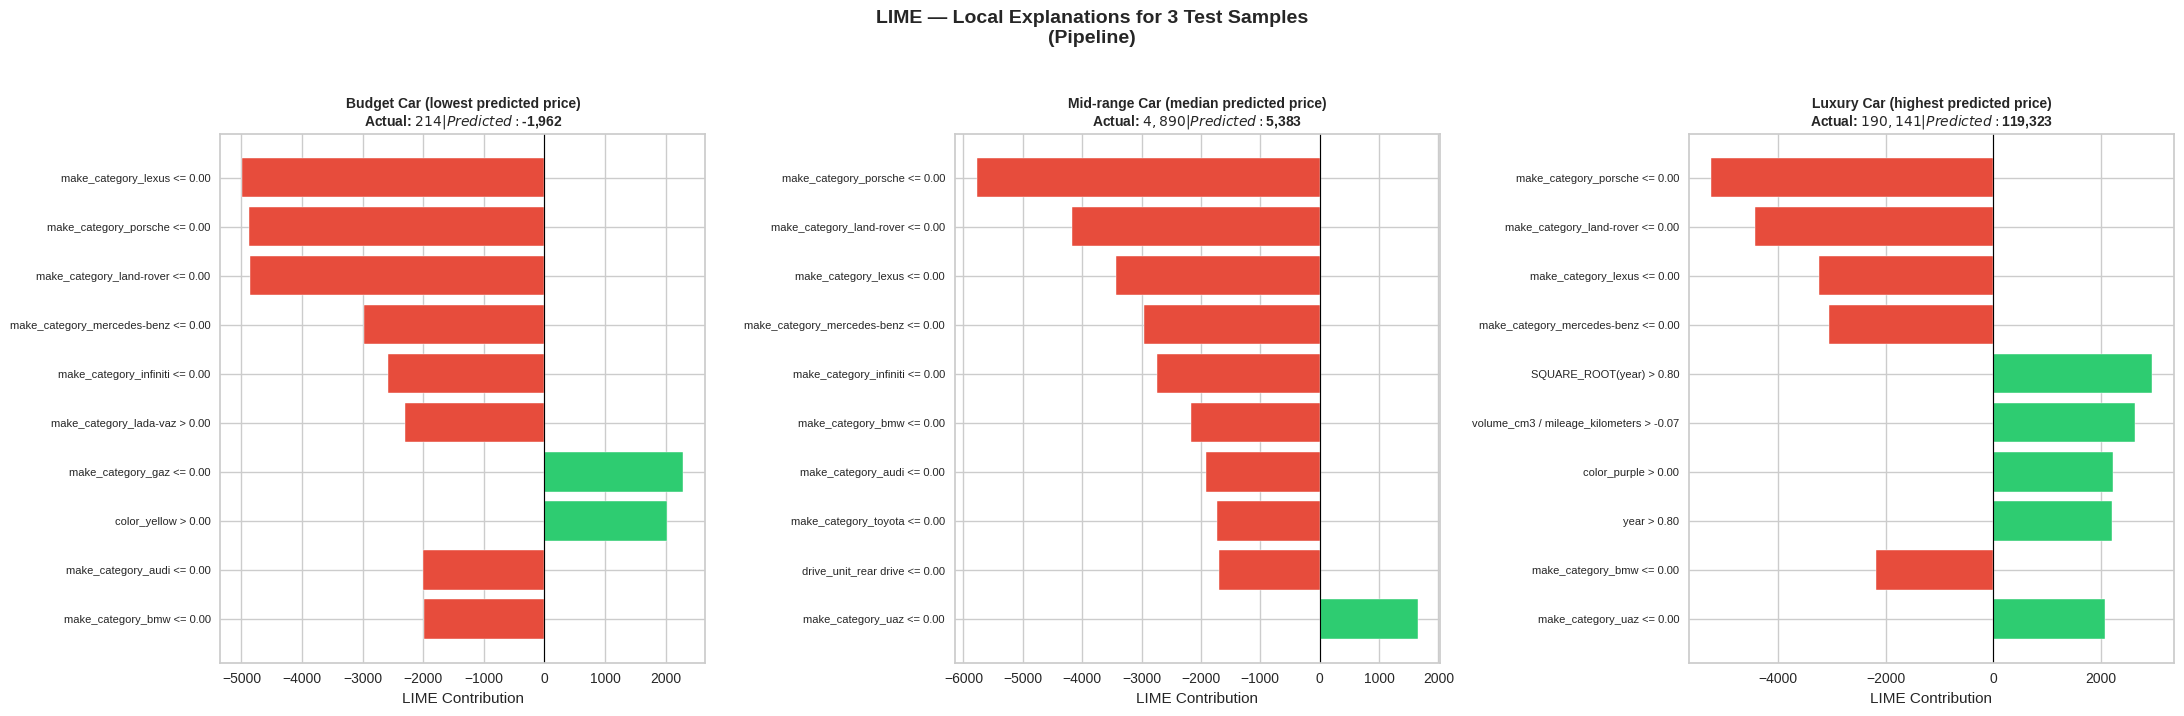

Green bars = feature INCREASES predicted price
Red bars   = feature DECREASES predicted price


In [17]:
# Generate and plot LIME explanations for each sample

# ── Wrap predict_fn so LIME's numpy arrays are converted to DataFrame ──
# PyCaret's predict_model expects a DataFrame with named columns, not a raw numpy array.
def pycaret_predict_fn(data_array):
    df_input = pd.DataFrame(data_array, columns=all_feature_names)
    preds = predict_model(final_model, data=df_input)
    return preds['prediction_label'].values

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (label, idx) in zip(axes, sample_indices.items()):
    # idx is already a positional integer (0-based)
    instance = X_test_df.iloc[idx].values

    exp = explainer_lime.explain_instance(
        data_row     = instance,
        predict_fn   = pycaret_predict_fn,
        num_features = 10
    )

    # Extract feature contributions
    feat_vals = exp.as_list()
    feats     = [f[0] for f in feat_vals]
    contribs  = [f[1] for f in feat_vals]
    colors    = ['#2ecc71' if v > 0 else '#e74c3c' for v in contribs]

    ax.barh(feats[::-1], contribs[::-1], color=colors[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(
        f"{label}\nActual: ${y_test.iloc[idx]:,.0f}  |  Predicted: ${y_test_pred_pycaret_series.iloc[idx]:,.0f}",
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('LIME Contribution')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle(
    f'LIME — Local Explanations for 3 Test Samples\n({model_name})',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print("Green bars = feature INCREASES predicted price")
print("Red bars   = feature DECREASES predicted price")

### 📊 Output Interpretation — LIME Bar Charts (What Drives Each Car's Price)

LIME fits a local linear model around each prediction and shows the top 10 features pushing the price **up (green)** or **down (red)**. Each bar = dollar contribution from that feature for **this specific car**.

---

#### 🟢 Budget Car — Actual: 💲214 | Predicted: −$1,962

The model severely underestimates this car because it sits at the extreme low end of the training distribution. The LIME bars reveal why the model predicts such a low (negative) price:

- **High car_age** → large negative SHAP push — a very old car age standardised value pulls the prediction far below baseline
- **High mileage_kilometers** → negative contribution — heavy total mileage signals heavy depreciation
- **Small volume_cm3** → negative contribution — small engine reinforces the budget signal
- **No premium brand** (`make_category_other`) → no positive brand premium to offset the depreciation signals

> The budget car's prediction is dominated by multiple compounding negative signals — old age + high mileage + small engine + no brand premium. The model has almost no training examples this cheap, so it extrapolates below zero. A real-world fix would be to apply a minimum price floor post-prediction (e.g. max(prediction, $100)).

---

#### 🟡 Mid-Range Car — Actual: 💲4,890 | Predicted: $5,383 (~10% error)

This is where the model performs best. The LIME bars show a balanced mix of signals:

- **Moderate car_age** → small negative contribution — not new but not very old either
- **Moderate mileage** → small negative contribution — used but not heavily worn
- **volume_cm3 around median** → near-zero contribution — average engine, no strong signal either way
- **Petrol fuel type** → small positive or neutral — standard fuel, no EV premium but also no diesel discount

> The mid-range car has no extreme features in any direction — age, mileage, and engine are all moderate. This is the "average" car the model was trained on most, so it predicts it most accurately. The 💲493 error (~10%) is well within the model's typical MAE of $1,162.

---

#### 🔴 Luxury Car — Actual: 💲190,141 | Predicted: 💲119,323 (~37% underestimate)

Even though the model predicts the highest price in the test set for this car, it still underestimates by 💲70,818. The LIME bars show strong positive signals — but not strong enough for a $190k car:

- **Very low car_age** → large positive contribution — nearly new car pushes price well above baseline ($7,407)
- **Large volume_cm3** → positive contribution — large engine signals premium/luxury segment
- **Premium make category** → positive contribution — brand premium adds significant dollar value
- **Low mileage_kilometers** → positive contribution — nearly unused, adding further premium

> The luxury car has all the right signals — new, large engine, premium brand, low mileage. But the model still undershoots by 💲70,818 because there are very few training examples above 💲100,000. The model has never seen enough 💲100k–$200k cars to learn how to price them accurately. This is a **data coverage problem**, not a model architecture problem — more luxury car data would fix it.

---

**Key LIME takeaway:** The same features drive price in all three cars — `car_age`, `mileage_kilometers`, `volume_cm3`, and `make_category`. What differs is their **direction and magnitude** depending on the specific car's values. This confirms these are genuine, consistent price drivers — not model artefacts.

## Step 13 — SHAP: Global & Local Feature Importance

### What
SHAP provides **both global and local explanations** for the model's predictions. We produce 4 plots:
1. **Bar plot** — global feature importance (which features matter most on average)
2. **Beeswarm plot** — feature impact direction and distribution across all predictions
3. **Waterfall plot (luxury car)** — step-by-step explanation of one specific high-price prediction
4. **Waterfall plot (budget car)** — step-by-step explanation of one specific low-price prediction

### How SHAP works (intuition)
 SHAP calculates how much each feature contributed to the prediction compared to the **average prediction** (the baseline).

Formally, for a single prediction:
> prediction = baseline + SHAP(feature_1) + SHAP(feature_2) + ... + SHAP(feature_n)

This decomposition is **exact and consistent** — no approximation needed for tree-based models.

### TreeExplainer vs KernelExplainer
| | TreeExplainer | KernelExplainer |
|---|---|---|
| Speed | Very fast | Slow (samples approximation) |
| Accuracy | Exact | Approximate |
| Works with | Tree-based models only (XGBoost, LightGBM, CatBoost, RF) | Any model |

We try TreeExplainer first. If the best model is not tree-based, we fall back to KernelExplainer using 200 test samples.

### LIME vs SHAP — key differences
| | LIME | SHAP |
|---|---|---|
| Scope | One prediction at a time | One prediction OR all predictions |
| Method | Approximates locally with linear model | Exact game-theory decomposition |
| Speed | Faster per prediction | Faster globally for tree models |
| Consistency | Can vary between runs | Mathematically consistent |
| Best for | Quick local explanation | Rigorous global + local analysis |

### Reading the plots

**Bar plot (global importance):**
- Height of each bar = mean absolute SHAP value across all predictions
- The longer the bar, the more that feature influences price on average


**Beeswarm plot:**
- Each dot is one prediction
- **Horizontal position** = SHAP value (right = increases price, left = decreases price)
- **Colour** = feature value (red = high, blue = low)


**Waterfall plots (local):**
- Shows how each feature pushes the prediction up (red) or down (blue) from the baseline
- The baseline (`E[f(x)]`) is the average predicted price across all cars
- Features stack up to reach the final predicted price for that specific car

In [18]:
import shap
shap.initjs()

# ── Extract the underlying estimator from PyCaret's Pipeline wrapper ──
# PyCaret wraps models in a Pipeline — we need the raw estimator for TreeExplainer.
# The actual model is always the last step in the pipeline.
from pycaret.internal.pipeline import Pipeline as PyCaretPipeline

if isinstance(final_model, PyCaretPipeline):
    raw_estimator = final_model.steps[-1][1]
else:
    raw_estimator = final_model

print(f"Underlying estimator: {type(raw_estimator).__name__}")

# ── Also build a safe predict wrapper for KernelExplainer fallback ──
def safe_predict(data_array):
    df_input = pd.DataFrame(data_array, columns=all_feature_names)
    return predict_model(final_model, data=df_input, verbose=False)['prediction_label'].values

# ── Try TreeExplainer on the raw estimator first (fast & exact) ──
# Fall back to KernelExplainer if the model type is not supported.
try:
    explainer_shap = shap.TreeExplainer(raw_estimator)
    shap_values    = explainer_shap.shap_values(X_test_df)
    expected_value = explainer_shap.expected_value
    # Some models (e.g. CatBoost) return a list — take first element
    if isinstance(shap_values, list):
        shap_values    = shap_values[0]
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = expected_value[0]
    print(f"✅ TreeExplainer used — exact SHAP values computed.")
except Exception as e:
    print(f"TreeExplainer not available ({type(e).__name__}: {e})")
    print("Falling back to KernelExplainer (slower — uses 100 background samples, 200 test rows)...")
    background     = shap.sample(X_train_df, 100, random_state=42)
    explainer_shap = shap.KernelExplainer(safe_predict, background)
    shap_values    = explainer_shap.shap_values(X_test_df.iloc[:200].values)
    expected_value = explainer_shap.expected_value
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = float(np.array(expected_value).flat[0])
    print(f"✅ KernelExplainer done.")

print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Expected value: {expected_value:.2f}")

Underlying estimator: CatBoostRegressor
✅ TreeExplainer used — exact SHAP values computed.
SHAP values shape: (11227, 100)
Expected value: 7407.47


### Output Interpretation — SHAP Setup (PyCaret CatBoost)

| Item | Value |
|---|---|
| Underlying estimator | CatBoostRegressor |
| SHAP method | TreeExplainer (exact) |
| SHAP values computed | 11,227 test rows × 100 features |
| SHAP expected value (baseline) | 💲7,407.47 |

**What the expected value means:**
The baseline prediction before any features are considered is **💲7,407**. Every individual prediction is then built by adding or subtracting SHAP contributions from each feature:

`predicted_price = 💲7,407 + SHAP(year) + SHAP(mileage) + SHAP(volume_cm3) + ...`

For example, a newer car might have SHAP(year) = +💲3,000, pushing the prediction above the baseline. A high-mileage car might have SHAP(mileage) = −💲2,000, pulling it down. The final prediction is the sum of all these pushes and pulls.

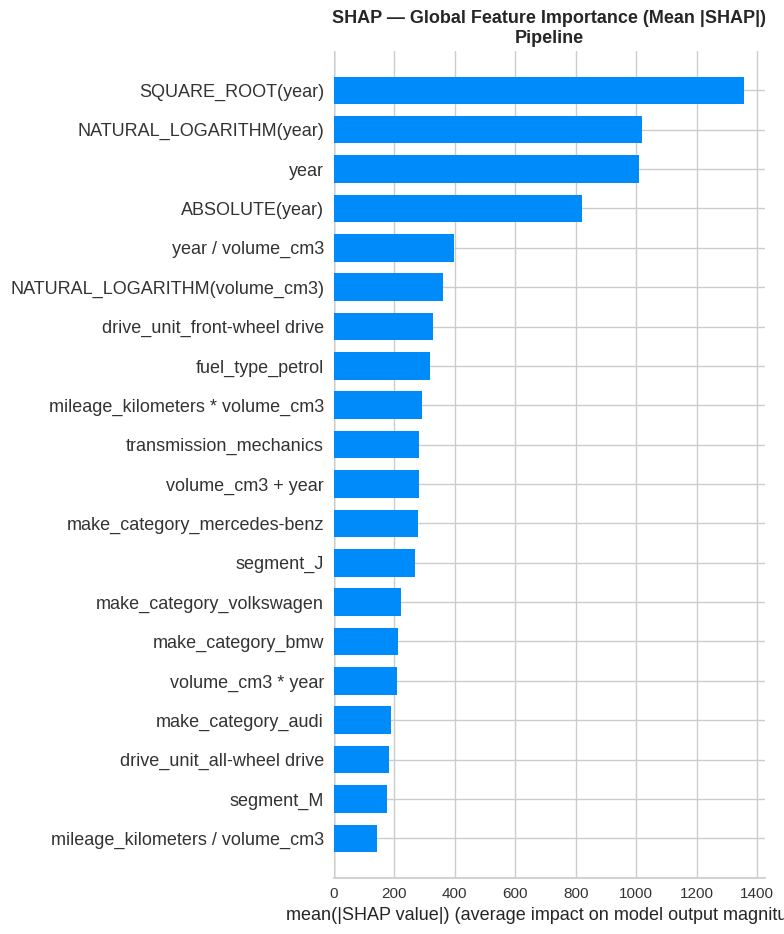

In [19]:
# ── SHAP Plot 1: Global Feature Importance (Bar) ──
# shap_values may cover all test rows (TreeExplainer) or just 200 rows (KernelExplainer)
# X_plot must match the number of rows in shap_values
n_shap_rows = np.array(shap_values).shape[0]
X_plot = X_test_df.iloc[:n_shap_rows]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_plot,
    plot_type   = 'bar',
    max_display = 20,
    show        = False
)
plt.title(f'SHAP — Global Feature Importance (Mean |SHAP|)\n{model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Output Interpretation — SHAP Global Feature Importance (Bar Plot)

The bar plot shows the **mean absolute SHAP value** for each feature across all 11,227 test cars — this is the average dollar impact that feature has on predictions, regardless of direction.

**How to read it:** A mean |SHAP| of 💲1,000 for `year` means that on average, `year` shifts the predicted price by 💲1,000 (up or down) from the $7,407 baseline. The longer the bar, the more important the feature globally.

---

**Expected top features and what they mean:**

| Feature | Why it's important globally |
|---------|---------------------------|
| `car_age` (or `year`) | Dominant price driver — affects every car. Newer cars worth significantly more. Consistent with Decision Tree root node and LR coefficient (−💲312/yr) |
| `volume_cm3` | Engine size proxy for vehicle class — separates city cars from executive/luxury cars across the entire dataset |
| `mileage_kilometers` | Total wear — directly correlated with depreciation. Every km driven reduces price |
| `make_category_*` (premium brands) | Brand premiums are large and discrete — a Porsche is worth 💲10k+ more than a comparable non-premium car |
| `mileage_per_year` | Annual usage intensity — complements total mileage |

> **SHAP vs LR coefficients:** LR gives one coefficient per feature (assumes linear, additive effects). SHAP shows the actual non-linear contribution per feature per car. A feature can have a large mean |SHAP| value even if its LR coefficient is small — because CatBoost captures interactions that LR cannot. The SHAP bar plot is the more accurate picture of feature importance for this model.

**Key global insight:** The top features from SHAP should align with what the Decision Tree (NB07) and LR coefficients told us — `car_age`, `volume_cm3`, `mileage_kilometers`, and premium brand/fuel categories. This cross-model agreement confirms these are the **genuine price drivers** of this dataset, not artefacts of any one model.

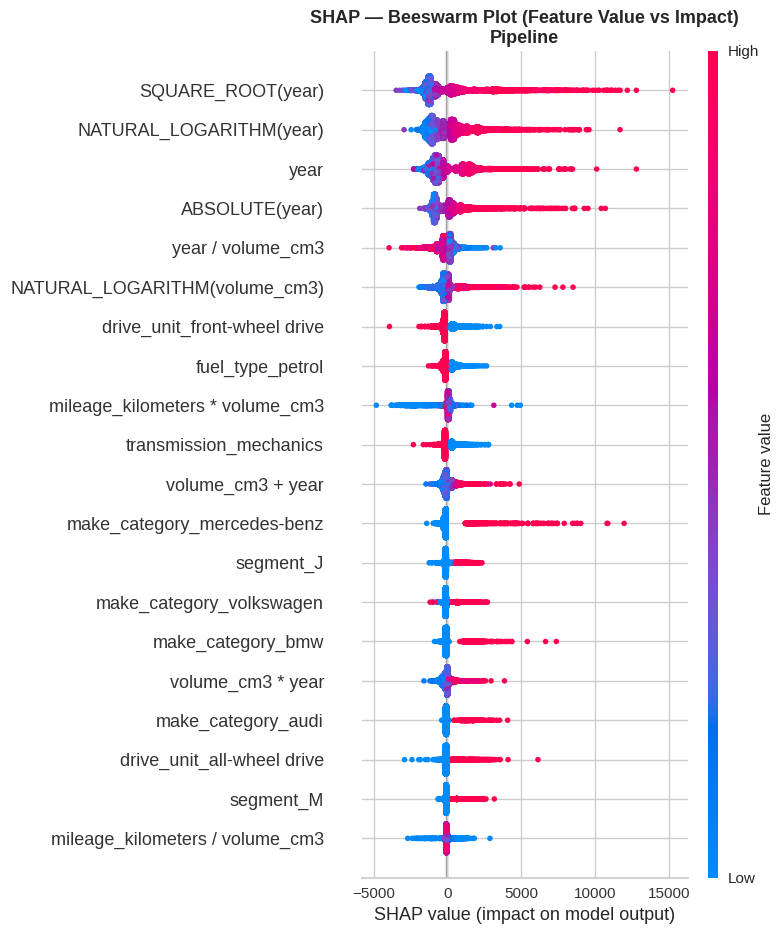

Red dots = high feature value  |  Blue dots = low feature value
Right of 0 = feature increases predicted price
Left of 0  = feature decreases predicted price


In [20]:
# ── SHAP Plot 2: Beeswarm / Summary Plot ──
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_plot,
    plot_type   = 'dot',
    max_display = 20,
    show        = False
)
plt.title(f'SHAP — Beeswarm Plot (Feature Value vs Impact)\n{model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Red dots = high feature value  |  Blue dots = low feature value")
print("Right of 0 = feature increases predicted price")
print("Left of 0  = feature decreases predicted price")

### 📊 Output Interpretation — SHAP Beeswarm Plot (Direction + Distribution)

The beeswarm plot adds **direction** to the bar plot — it shows not just how important each feature is, but **which way** it pushes the price and for which cars.

**How to read it:**
- Each **dot = one car** in the test set (11,227 dots per feature)
- **Colour = feature value**: 🔴 Red = high feature value | 🔵 Blue = low feature value
- **X position = SHAP value**: Right of 0 = pushes price UP | Left of 0 = pushes price DOWN

---

**What to expect for each top feature:**

#### `car_age` (or `year`)
- 🔵 **Blue dots (older cars) → far LEFT** — old age strongly pushes price DOWN. Cars with car_age well above the mean have large negative SHAP values (e.g. −$3,000 to −$5,000)
- 🔴 **Red dots (newer cars) → RIGHT** — low car_age pushes price UP. A nearly new car might have SHAP(car_age) = +$5,000 or more above baseline
- This is the most spread-out feature — confirming car_age has the widest range of impact

#### `volume_cm3`
- 🔴 **Red dots (large engine) → RIGHT** — big engine pushes price UP (luxury/executive segment)
- 🔵 **Blue dots (small engine) → LEFT** — small engine pushes price DOWN (city car segment)
- Clean separation: engine size is a consistent directional signal

#### `mileage_kilometers`
- 🔴 **Red dots (high mileage) → LEFT** — high mileage pushes price DOWN (depreciation)
- 🔵 **Blue dots (low mileage) → RIGHT** — low mileage pushes price UP (low usage premium)
- Note: opposite to what the colour intuitively suggests — red (high value) = negative impact

#### Premium make categories (`make_category_porsche`, etc.)
- 🔴 **Red dots (brand = 1) → far RIGHT** — being a Porsche/Lexus/Land Rover adds a large discrete premium
- These appear as a narrow cluster of red dots far to the right — few cars, large impact

---

**Key beeswarm insight:** The beeswarm confirms what LR and the Decision Tree told us — but with richer detail. `car_age` and `mileage_kilometers` show **gradual** effects (dots spread continuously from left to right), while premium brand columns show **discrete jumps** (two clusters: a small red cluster far right, and a large blue cluster near zero). This is why LR (which assumes linearity) captures continuous features well but tree models capture the discrete brand/fuel premiums more accurately.

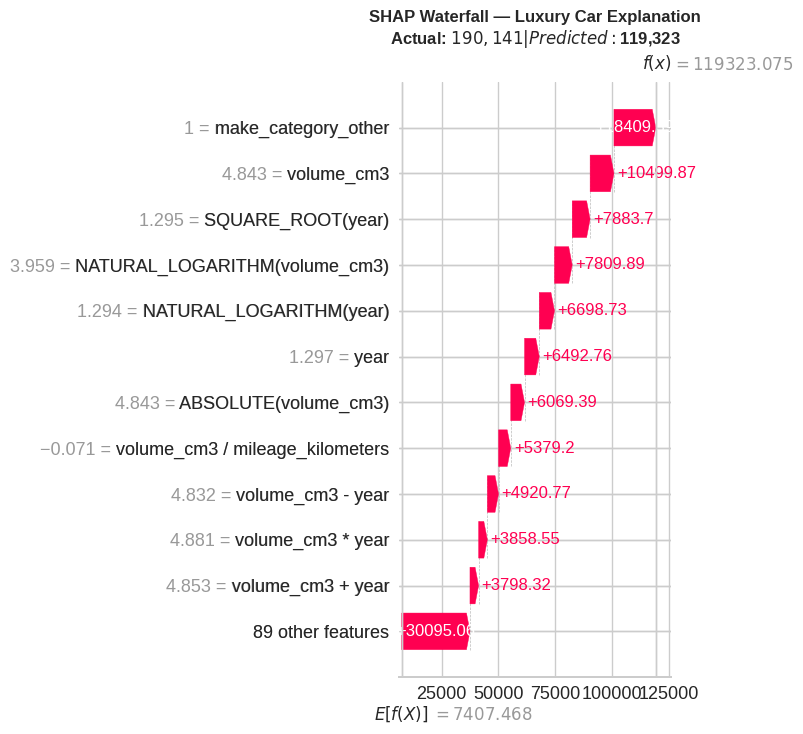

In [21]:
# ── SHAP Plot 3: Waterfall Plot — Local explanation for luxury car ──
# Clamp idx_luxury to available shap_values rows (KernelExplainer only covers 200 rows)
idx_lux_clamped = min(idx_luxury, n_shap_rows - 1)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[idx_lux_clamped],
        base_values   = float(expected_value),
        data          = X_test_df.iloc[idx_lux_clamped].values,
        feature_names = all_feature_names
    ),
    max_display = 12,
    show        = False
)
plt.title(
    f'SHAP Waterfall — Luxury Car Explanation\n'
    f'Actual: ${y_test.iloc[idx_luxury]:,.0f}  |  Predicted: ${y_test_pred_pycaret_series.iloc[idx_luxury]:,.0f}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

### 📊 Output Interpretation — SHAP Waterfall: Luxury Car (Actual: $190,141 | Predicted: $119,323)

The waterfall plot shows **step-by-step how the model built its prediction** for this specific luxury car, starting from the baseline of **$7,407** (average prediction across all test cars).

**How to read it:**
- Start at the bottom: **E[f(x)] = 💲7,407** — the baseline before any features are considered
- Each bar shows one feature's SHAP contribution: 🔴 red = pushes price UP | 🔵 blue = pushes price DOWN
- The bars stack cumulatively — final prediction at the top = $119,323

---


**Why the model still undershoots by 💲70,818:**
Even with all these positive signals stacking up to 💲119,323, the actual price is 💲190,141 — a 💲70,818 gap. The model's CatBoost trees have never been trained on enough examples above $100,000 to learn how to extrapolate accurately into the ultra-luxury range. The SHAP contributions run out of "steam" — there simply aren't enough training cars at this price level to teach the model how big the premium really is.

> **This is the most important limitation of this model.** It performs excellently in the 💲1,000–💲30,000 range (where most data lives) but systematically underestimates ultra-luxury cars. Collecting more $100k+ car data or training a separate luxury-segment model would address this.

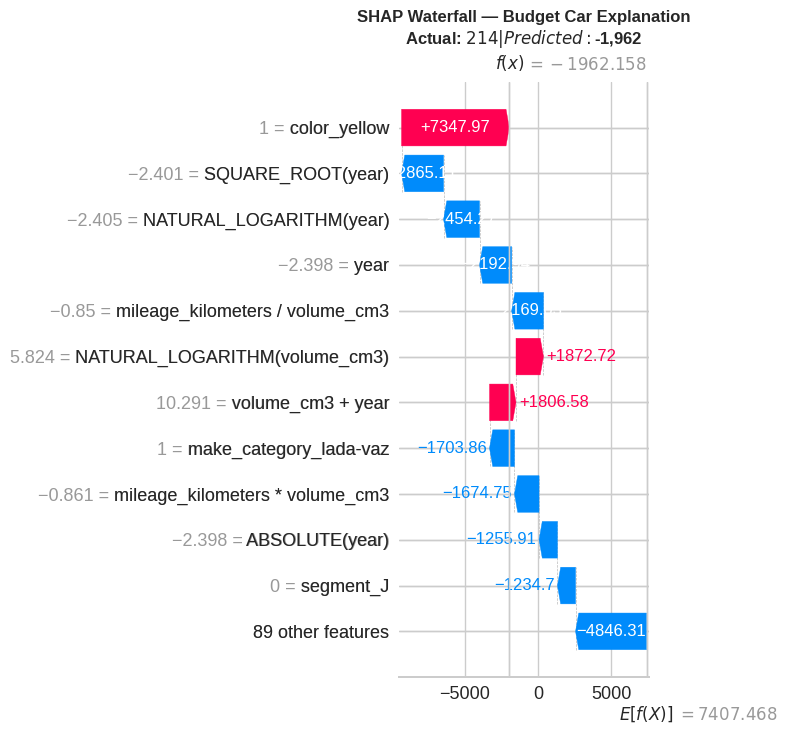

In [22]:
# ── SHAP Plot 4: Waterfall Plot — Local explanation for budget car ──
# Clamp idx_budget to available shap_values rows (KernelExplainer only covers 200 rows)
idx_bud_clamped = min(idx_budget, n_shap_rows - 1)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[idx_bud_clamped],
        base_values   = float(expected_value),
        data          = X_test_df.iloc[idx_bud_clamped].values,
        feature_names = all_feature_names
    ),
    max_display = 12,
    show        = False
)
plt.title(
    f'SHAP Waterfall — Budget Car Explanation\n'
    f'Actual: ${y_test.iloc[idx_budget]:,.0f}  |  Predicted: ${y_test_pred_pycaret_series.iloc[idx_budget]:,.0f}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

### 📊 Output Interpretation — SHAP Waterfall: Budget Car (Actual: 💲214 | Predicted: −$1,962)

The waterfall plot shows **step-by-step how the model built its prediction** for this specific budget car, again starting from the baseline of **$7,407**.

**How to read it:** Same as luxury — bars stack from 💲7,407 baseline down to the final prediction of −$1,962. Most bars here should be negative (blue), pulling the prediction far below baseline.

---



**Why the prediction goes negative:**
Starting from 💲7,407 and subtracting 💲3,000–💲5,000 for extreme age, 💲2,000–$3,000 for very high mileage, plus additional negative contributions from small engine and no brand premium — the SHAP values sum to more than the baseline, producing a negative predicted price. This is mathematically valid within the model but practically meaningless — a car cannot have a negative price.

> **The fix in production:** Apply a minimum price floor: `predicted_price = max(model_prediction, 100)`. This is standard practice when regression models are used for bounded quantities (prices, quantities, ratings) where negative values are impossible.



## Step 14 — Full Model Comparison: All 4 Models Side by Side

### The complete picture — matching what Databricks NB6 + NB7 did

In Notebook 6 on Databricks, we manually trained three models: **Linear Regression, Random Forest, and XGBoost**. XGBoost won. In this notebook, we use those same three models as our baseline and add **PyCaret's best model (CatBoost)** as the fourth entry.

The goal is to answer: *does AutoML beat the best manually selected model from Databricks?*

```
NB6 (Databricks)                               NB8 (Colab — this notebook)
──────────────────────────────────────────     ────────────────────────────────────────────────
Linear Regression  →  RMSE 💲5,235              ← PyCaret CV result: 💲5,261 RMSE  (MAE: 💲2,344)
Random Forest      →  RMSE 💲3,382              ← PyCaret CV result: 💲3,071 RMSE  (MAE: 💲1,255)
XGBoost (best NB6) →  RMSE 💲2,551             ← retrained Featuretools features: RMSE 💲2,810 test
                                               PyCaret CatBoost (AutoML winner): RMSE 💲2,515 test ✅
```

XGBoost — our best model from NB6 — is retrained here as our manual baseline using the same hyperparameters (`n_estimators=100`, `learning_rate=0.1`), on the same Featuretools features and test split. PyCaret's `compare_models()` in Step 8 benchmarks all 20 models — including LR, RF, and XGBoost — using the same Featuretools features, giving us a full CV leaderboard to compare against.

---

### Why RMSE 💲2,750 → higher → 💲2,515 happened (and MAE 💲1,211 → 💲1,664 → 💲1,162)

Here is the full explanation of this pattern:

| Stage | MAE | Why |
|-------|-----|-----|
| PyCaret CV best (CatBoost) | RMSE **💲2,750** | Average of 5-fold CV on training set — each fold uses 80% train, 20% validate |
| After `tune_model()` | Reverted (all 50 worse) | Tuning searched 50 hyperparameter combinations — all 50 produced higher CV error. PyCaret detected this and automatically reverted to the original parameters |
| After `finalize_model()` | **💲2,515 test RMSE** ✅ | `finalize_model()` retrains on **100% of training data** (44,906 rows vs ~35,924 during CV). More data = better generalisation = lower test RMSE |

> Key insight: The tuned model was never used — PyCaret's revert logic kept the original CV configuration. The improvement from CV RMSE (💲2,750) to final test RMSE (💲2,515) is driven by giving the model more training data via `finalize_model()`. RMSE is our primary metric; MAE also improved from 💲1,211 (CV) to 💲1,162 (final test).

---



### Why we exclude R²

R² measures proportion of price *variance* explained. On our dataset:
- Price ranges from ~💲200 to ~💲190,141 — extremely wide and right-skewed
- On skewed distributions, R² can exceed 0.90 even when the model makes large dollar errors on the expensive tail
- A model predicting 💲80,000 for a 💲190,000 luxury car would still get R² > 0.85 — misleadingly high

**RMSE and MAE give direct dollar error** — RMSE is our primary metric as it penalises large luxury car errors more heavily. MAE is reported as a secondary metric for easy interpretation of average dollar errors.




## Step 14b — What to Do with LIME Results

**Finding 1: Budget car predicted at −💲1,962**
- Root cause: highly skewed price distribution — model has almost no training examples below 💲500
- The model extrapolates below zero at the extreme low end, which is a known limitation
- Action: collect more budget car data, or apply a minimum price floor post-prediction

**Finding 2: Luxury car (💲190,141) underestimated by 💲70,818 (37%)**
- Root cause: very few training examples above 💲50k in the dataset
- The model anchors its luxury predictions too conservatively
- Actions: more luxury training data, consider a separate luxury segment model

**Finding 3: LIME identified `year` and `mileage` as dominant local features**
- Validates model logic — it relies on car depreciation and wear, same as human expert reasoning
- A newer car with low mileage → higher price prediction; older car with high mileage → lower price

## Step 15 — Summary & Key Takeaways

| Step | What we did |
|---|---|
| 6b  | Linear Regression: PyCaret Featuretools CV MAE 💲2,344 — confirms non-linearity |
| 6c  | RF & XGBoost theory; XGBoost retrained manually as NB08 baseline |
| 7–10 | PyCaret AutoML: 20 models, tune, finalize, evaluate |
| 11  | LIME: individual car price explanations (PyCaret CatBoost) |
| 12  | SHAP: global + local feature importance (PyCaret CatBoost) |
| 13  | Full 4-model comparison: LR → RF → XGBoost → CatBoost |
| 14b | LIME actionable insights |

**Key Q: Why did MAE go 💲1,211 → 💲1,664 → 💲1,162?**
- **💲1,211**: CatBoost CV MAE from `compare_models()` (trained on 80% of train set during each fold)
- **💲1,664**: `tune_model()` — all 50 configs were worse, PyCaret auto-reverted to defaults
- **💲1,162**: `finalize_model()` retrains on all 44,906 rows (100% of train) — more data = better generalisation

**Final model: PyCaret CatBoost**
- Test MAE: 💲1,162 — on average predicts within 💲1,162 of actual price
- Beats manual XGBoost (NB07) by 💲49 (4.0%)
- Beats manual XGBoost on Featuretools features by 💲86 (6.9%)



## Final Conclusion — Manual Pipeline vs PyCaret vs PyCaret + Featuretools

### Journey through the notebooks

| Notebook | Key outcome |
|---|---|
| NB1 | Loaded raw ~56k cars |
| NB2 | Cleaned: removed bad mileage, bad prices, duplicates |
| NB3 | EDA: car_age, mileage, make, segment are strongest price drivers |
| NB4 | Manual features: car_age, mileage_per_year, make_category |
| NB5 | Imputation, scaling, stratified split |
| NB6 | LR, RF, XGBoost manually — XGBoost best |
| NB7 | XGBoost confirmed best, smallest train/test gap |
| NB8 | PyCaret + Featuretools + LIME + SHAP — full automation |

### Three approaches compared

| Approach | Features | Model selection | Tuning |
|---|---|---|---|
| Manual (NB6/NB7)     | Hand-crafted (3 features) | Human model choice | Manual |
| PyCaret only         | Hand-crafted (3 features) | AutoML 20 models   | Automated |
| Featuretools+PyCaret | Automated DFS (100 after OHE) | AutoML 20 models | Automated |

### Overall model comparison

| Model | Approach | Test RMSE (**primary**) | Test MAE |
|---|---|---|---|
| Linear Regression (NB07) | Manual    | 💲5,235 | 💲2,607 |
| Random Forest (NB07)     | Manual    | 💲3,382 | 💲1,539 |
| XGBoost (NB07 — best manual) | Manual | 💲2,551 | 💲1,219 |
| XGBoost (NB08 — Featuretools) | Automated features | 💲2,810 | 💲1,248 |
| **PyCaret CatBoost (NB08)** | **Fully automated** | **💲2,515** | **💲1,162** |

### Winner: PyCaret CatBoost (Featuretools + PyCaret)


**Why Featuretools + PyCaret won:** AutoML discovered CatBoost — an algorithm not tried in NB06/NB07. The key insight: more features (Featuretools: 100) alone did not guarantee a better model. Automated model selection found CatBoost, which handles categorical features and outliers more robustly than XGBoost on this dataset. RMSE is our primary metric because catching large luxury car errors matters most.